
### Dataset Loading and Basic Exploration

In [1]:
# ================================
# Import Required Libraries
# ================================

# importing Data Handling libraries:
import pandas as pd
import numpy as np

# importing Data Visualization Libraries:
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language processing Libraries:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


# Text processing Libraries:
import string
import re

from wordcloud import WordCloud

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Deep Learning Libraries
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, Dense, Bidirectional

In [2]:
# Download required NLTK datasets

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
# Load dataset

df = pd.read_csv("review.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,review,sentiment
0,0,Not sure who was more lost - the flat characte...,0
1,1,Attempting artiness with black & white and cle...,0
2,2,Very little music or anything to speak of.,0
3,3,The best scene in the movie was when Gerardo i...,1
4,4,"The rest of the movie lacks art, charm, meanin...",0


In [4]:
# Check number of rows and columns

df.shape

(999, 3)

In [5]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  999 non-null    int64 
 1   review      999 non-null    object
 2   sentiment   999 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 23.5+ KB


In [6]:
# Display data types

df.dtypes

Unnamed: 0     int64
review        object
sentiment      int64
dtype: object

In [7]:
# Check null values

df.isnull().sum()

Unnamed: 0    0
review        0
sentiment     0
dtype: int64

In [8]:
# Remove rows with missing values

df = df.dropna()

In [9]:
# Count values of sentiment
# The function value_counts() is used to count how many times each sentiment value appears in the date s 
# 1= positive & 0=Negative 
df['sentiment'].value_counts()

sentiment
1    500
0    499
Name: count, dtype: int64


### Text Visualization


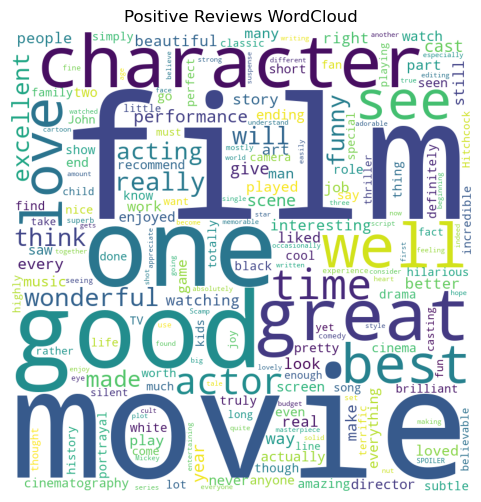

In [10]:
# Word Cloud for the positive reviews
# Filter positive reviews

positive_reviews = df[df['sentiment'] == 1]['review']

# Generate word cloud

wc = WordCloud(width=800, height=800, background_color='white').generate(" ".join(positive_reviews))

plt.figure(figsize=(6,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

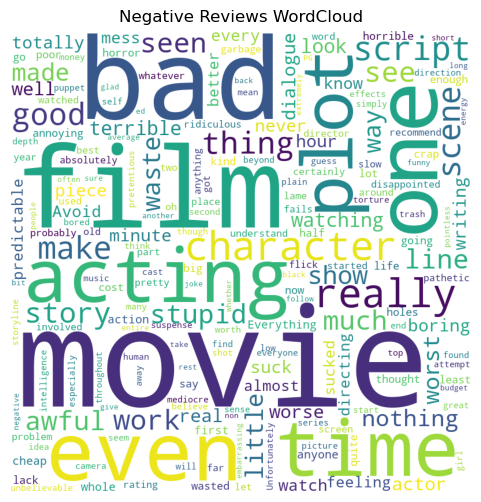

In [11]:
# Word Cloud for the Negative reviews
# Filter negative reviews

negative_reviews = df[df['sentiment'] == 0]['review']

wc = WordCloud(width=800, height=800, background_color='white').generate(" ".join(negative_reviews))

plt.figure(figsize=(6,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

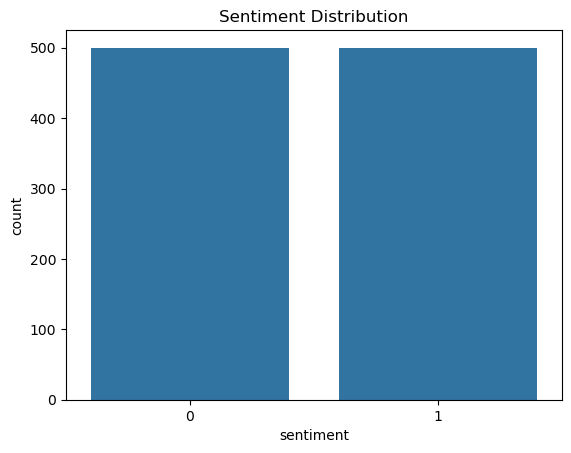

In [12]:
# Sentiment Distribution Plot

sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")
plt.show()


### NLP + Data preparation


In [13]:
# Initialize Tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [14]:
# Text cleaning function
# created a function caled clean_text
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Join words
    text = " ".join(tokens)

    return text

In [15]:
# Applying Text Cleaning 

# Create cleaned text column

df['cleaned_review'] = df['review'].apply(clean_text)

df.head()

,Unnamed: 0,review,sentiment,cleaned_review
0,0,Not sure who was more lost - the flat characte...,0,sure lost flat character audience nearly half ...
1,1,Attempting artiness with black & white and cle...,0,attempting artiness black white clever camera ...
2,2,Very little music or anything to speak of.,0,little music anything speak
3,3,The best scene in the movie was when Gerardo i...,1,best scene movie gerardo trying find song keep...
4,4,"The rest of the movie lacks art, charm, meanin...",0,rest movie lack art charm meaning emptiness wo...


In [16]:
# converting the clean text into numerical by using 
# Feature Extraction ( TF-IDF) 
#Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into vectors
X = tfidf.fit_transform(df['cleaned_review'])
y = df['sentiment']


### Machine Learning Models

In [17]:
# Train test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Logistc Regression Model


In [18]:
# Train model

lr = LogisticRegression()

lr.fit(X_train, y_train)

# Predictions

y_pred_lr = lr.predict(X_test)

# Accuracy

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)

# Classification Report

print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.84      0.72      0.77       106
           1       0.72      0.84      0.78        94

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.77       200
weighted avg       0.78      0.78      0.77       200



In [19]:
# Confusion Matrix (Normal)

cm = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[76 30]
 [15 79]]


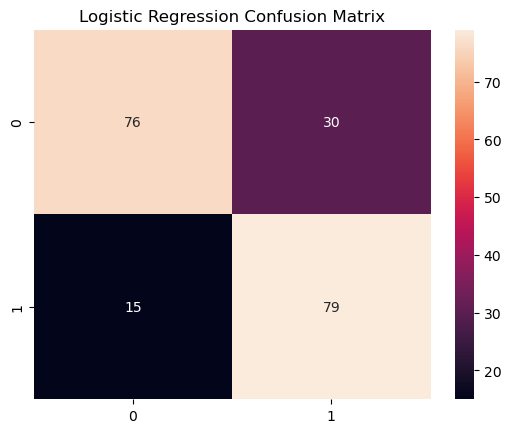

In [20]:
# Confusion Matrix using heat map..just for visualize

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Logistic Regression Confusion Matrix")
plt.show()

 Naive Bayes Model

In [21]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.78
              precision    recall  f1-score   support

           0       0.80      0.77      0.79       106
           1       0.76      0.79      0.77        94

    accuracy                           0.78       200
   macro avg       0.78      0.78      0.78       200
weighted avg       0.78      0.78      0.78       200



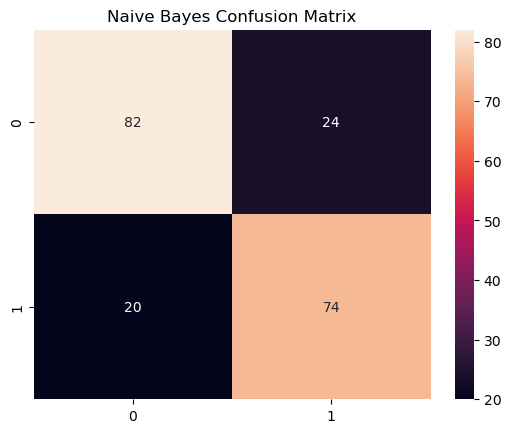

In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Naive Bayes Confusion Matrix")
plt.show()


### Deep Learning Models

In [23]:
# Tokenization 
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_review'])

sequences = tokenizer.texts_to_sequences(df['cleaned_review'])


In [24]:
# Padding 
max_length = 100

X_pad = pad_sequences(sequences, maxlen=max_length)

In [25]:
# Train Test Split
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_pad, y, test_size=0.2, random_state=42)

Simple RNN 

In [26]:
model_rnn = Sequential()

model_rnn.add(Embedding(5000, 64, input_length=max_length))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_rnn.summary()

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Train Model 
history_rnn = model_rnn.fit(X_train_dl, y_train_dl,
                            epochs=5,
                            batch_size=32,
                            validation_data=(X_test_dl, y_test_dl))

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.5269 - loss: 0.6931 - val_accuracy: 0.6200 - val_loss: 0.6837
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8786 - loss: 0.5765 - val_accuracy: 0.6400 - val_loss: 0.6676
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9449 - loss: 0.3599 - val_accuracy: 0.6800 - val_loss: 0.6280
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9675 - loss: 0.1901 - val_accuracy: 0.6650 - val_loss: 0.6894
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9850 - loss: 0.1043 - val_accuracy: 0.6300 - val_loss: 0.7167


Bidirectional RNN 

In [28]:
model_birnn = Sequential()

model_birnn.add(Embedding(5000, 64, input_length=max_length))
model_birnn.add(Bidirectional(SimpleRNN(64)))
model_birnn.add(Dense(1, activation='sigmoid'))

model_birnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_birnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_birnn = model_birnn.fit(X_train_dl, y_train_dl,
                                epochs=5,
                                batch_size=32,
                                validation_data=(X_test_dl, y_test_dl))

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 120ms/step - accuracy: 0.5094 - loss: 0.6969 - val_accuracy: 0.4850 - val_loss: 0.6927
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.7096 - loss: 0.6129 - val_accuracy: 0.6200 - val_loss: 0.6653
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.8448 - loss: 0.4747 - val_accuracy: 0.5700 - val_loss: 0.6682
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.8936 - loss: 0.3208 - val_accuracy: 0.5950 - val_loss: 0.6817
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9374 - loss: 0.2471 - val_accuracy: 0.5950 - val_loss: 0.6799


GRU Model

In [30]:
model_gru = Sequential()

model_gru.add(Embedding(5000, 64, input_length=max_length))
model_gru.add(GRU(64))
model_gru.add(Dense(1, activation='sigmoid'))

model_gru.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_gru = model_gru.fit(X_train_dl, y_train_dl,
                            epochs=5,
                            batch_size=32,
                            validation_data=(X_test_dl, y_test_dl))

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 158ms/step - accuracy: 0.5131 - loss: 0.6920 - val_accuracy: 0.5950 - val_loss: 0.6878
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - accuracy: 0.8198 - loss: 0.6526 - val_accuracy: 0.7050 - val_loss: 0.6389
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - accuracy: 0.8173 - loss: 0.5068 - val_accuracy: 0.6500 - val_loss: 0.5920
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.9024 - loss: 0.3662 - val_accuracy: 0.7300 - val_loss: 0.5586
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.9424 - loss: 0.2078 - val_accuracy: 0.7650 - val_loss: 0.5567


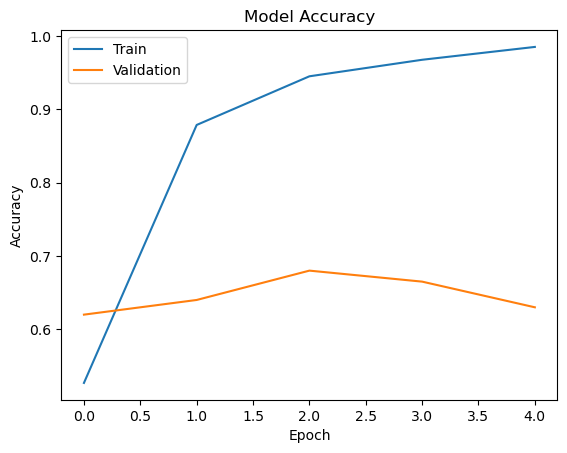

In [32]:
""" Accuracy & Loss Graphs """
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

### Model Evaluation

In [33]:
# RNN Evaluation

loss, rnn_accuracy = model_rnn.evaluate(X_test_dl, y_test_dl)

print("Simple RNN Accuracy:", rnn_accuracy)


# Bidirectional RNN

loss, birnn_accuracy = model_birnn.evaluate(X_test_dl, y_test_dl)

print("Bidirectional RNN Accuracy:", birnn_accuracy)


# GRU

loss, gru_accuracy = model_gru.evaluate(X_test_dl, y_test_dl)

print("GRU Accuracy:", gru_accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6300 - loss: 0.7167
Simple RNN Accuracy: 0.6299999952316284
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5950 - loss: 0.6799
Bidirectional RNN Accuracy: 0.5950000286102295
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.7650 - loss: 0.5567
GRU Accuracy: 0.7649999856948853


### COMPARATIVE ANALYSIS

In [34]:
results = {

    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Simple RNN",
        "Bidirectional RNN",
        "GRU"
    ],

    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        rnn_accuracy,
        birnn_accuracy,
        gru_accuracy
    ]
}

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.775
1,Naive Bayes,0.780
2,Simple RNN,0.630
3,Bidirectional RNN,0.595
4,GRU,0.765


### Final Result

In [35]:
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Naive Bayes
Accuracy           0.78
Name: 1, dtype: object



### DEPOYMENT OF THE PROJET


Saving Machine Learning Models

In [36]:
# Saving Machine Learning Models 
import pickle

pickle.dump(lr, open("lr_model.pkl", "wb"))
pickle.dump(nb, open("nb_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

Saving Deep Learning Models

In [37]:
# Saving Deep Learning Models
model_rnn.save("rnn_model.h5")
model_birnn.save("birnn_model.h5")
model_gru.save("gru_model.h5")

Saving Toenizer

In [38]:
# Saving Toenizer
pickle.dump(tokenizer, open("tokenizer.pkl","wb"))

In [39]:
import os
os.getcwd()

'C:\\Users\\user'